Import liblary

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

Predict menggunakan foto atau data baru

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 906ms/step
⚠ Model tidak yakin dengan prediksi.
Confidence: 41.18 %


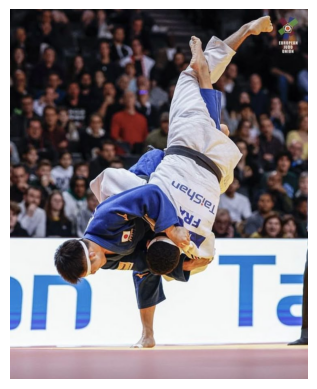

In [6]:
# 1. Load Model
model = tf.keras.models.load_model("sports_classification_model.keras")

# 2. Daftar Kelas
class_names = ['basketball', 'boxing', 'baseball', 'tennis', 'judo']

# 3. Path Gambar 
img_path = "Joshiro Maruyama’s recent uchi-mata.jpg"

# 4. Load & Preprocess Gambar
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# 5. Predict
prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

# 6. Threshold Confidence jika ada gambar yang kurang dari 0.6
threshold = 0.6

plt.imshow(image.load_img(img_path))
plt.axis("off")

if confidence < threshold:
    print("⚠ Model tidak yakin dengan prediksi.")
    print("Confidence:", round(float(confidence)*100, 2), "%")
else:
    print("Predicted Class:", predicted_class)
    print("Confidence:", round(float(confidence)*100, 2), "%")

Kesimpulan:

Model berhasil melakukan prediksi dengan data baru tetapi di samping itu model hanya bisa prediksi ke 5 kelas olahraga yaitu basketball, baseball, boxing, judo, tennis. tetapi untuk prediksi olahraga judo model kurang bisa memprediksi olahraga tersebut. Untuk akurasi confidence level mungkin terlihat kecil karena test set dari dataset yang saya temukan itu hanya sedikit jadi model kurang bisa belajar banyak gambar dan banyak angle dari ke 5 olahraga tersebut.

Hugging face link:
https://huggingface.co/spaces/Raifky/sport_predict